In [11]:
import numpy as np
import pandas as pd
import time
import statistics as stats
from sko.PSO import PSO
from sko.DE import DE

# 1. Definim les funcions objectiu en n dimensions
def rosenbrock(x):
    return sum(100.0 * (x[1:] - x[:-1]**2.0)**2.0 + (1 - x[:-1])**2.0)

def griewank(x):
    part1 = sum(x**2) / 4000.0
    part2 = np.prod(np.cos(x / np.sqrt(np.arange(1, len(x) + 1))))
    return 1.0 + part1 - part2

# 2. Funció genèrica per fer el Sweep del PSO
def PSO_Sweep(func, n_dim, lb, ub, pop, max_iter, w, c1, c2, rounds):
    errors = []
    for j in range(rounds):
        pso = PSO(func=func, n_dim=n_dim, pop=pop, max_iter=max_iter, lb=lb, ub=ub, w=w, c1=c1, c2=c2)
        pso.run()
        errors.append(pso.gbest_y[0]) # Guardem el millor fitness
        
    min_err = min(errors)
    avg_err = stats.mean(errors)
    std_err = stats.stdev(errors) if len(errors) > 1 else 0.0
    return min_err, avg_err, std_err

# Configuració bàsica
dimensions = 4
lower_bound = [-600] * dimensions # Límits típics per Griewank
upper_bound = [600] * dimensions
rounds_sweep = 30
def_pop = 50
def_iter = 150

results_pso = []

print(f"🚀 Iniciant Parameter Sweep PSO - Griewank {dimensions}D...")

# Escombrat de Inèrcia (w) i Factors (c1, c2)
# Ens assegurem de complir Engelbrecht: c1 + c2 <= 4
configs = [
    {'w': 0.8, 'c1': 0.5, 'c2': 0.5}, # Exploració moderada
    {'w': 0.9, 'c1': 1.5, 'c2': 1.5}, # Exploració alta (c1+c2 = 3)
    {'w': 0.4, 'c1': 2.0, 'c2': 2.0}, # Convergència ràpida (c1+c2 = 4)
    {'w': 0.9, 'c1': 0.1, 'c2': 3.9}  # Molt social, poc cognitiu (c1+c2 = 4)
]

for cfg in configs:
    w, c1, c2 = cfg['w'], cfg['c1'], cfg['c2']
    print(f"\nProvant PSO -> w: {w}, c1: {c1}, c2: {c2}...")
    start = time.time()
    min_e, avg_e, std_e = PSO_Sweep(griewank, dimensions, lower_bound, upper_bound, def_pop, def_iter, w, c1, c2, rounds_sweep)
    results_pso.append({'Alg': 'PSO', 'w': w, 'c1': c1, 'c2': c2, 'Avg Fit': avg_e, 'Min Fit': min_e, 'Std Dev': std_e})
    print(f"  -> Fet en {time.time()-start:.2f}s | Avg: {avg_e:.4f} | Min: {min_e:.4f} | Std: {std_e:.4f}")

df_pso = pd.DataFrame(results_pso)
print("\n" + "="*70)
print("🏆 RESULTATS PSO - GRIEWANK 10D 🏆")
print("="*70)
print(df_pso.to_string(index=False))

🚀 Iniciant Parameter Sweep PSO - Griewank 4D...

Provant PSO -> w: 0.8, c1: 0.5, c2: 0.5...
  -> Fet en 2.14s | Avg: 0.0457 | Min: 0.0099 | Std: 0.0283

Provant PSO -> w: 0.9, c1: 1.5, c2: 1.5...
  -> Fet en 1.92s | Avg: 0.5215 | Min: 0.0726 | Std: 0.1977

Provant PSO -> w: 0.4, c1: 2.0, c2: 2.0...
  -> Fet en 1.95s | Avg: 0.0283 | Min: 0.0000 | Std: 0.0184

Provant PSO -> w: 0.9, c1: 0.1, c2: 3.9...
  -> Fet en 2.10s | Avg: 11.4575 | Min: 0.9870 | Std: 27.0388

🏆 RESULTATS PSO - GRIEWANK 10D 🏆
Alg   w  c1  c2   Avg Fit  Min Fit   Std Dev
PSO 0.8 0.5 0.5  0.045715 0.009857  0.028275
PSO 0.9 1.5 1.5  0.521493 0.072599  0.197723
PSO 0.4 2.0 2.0  0.028345 0.000001  0.018362
PSO 0.9 0.1 3.9 11.457457 0.987006 27.038820



Generant la corba de convergència per a w=0.4, c1=2.0, c2=2.0...


C:\Users\Enric\AppData\Local\Temp\ipykernel_19652\2439074605.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  final_fitness = float(fitness_history[-1])


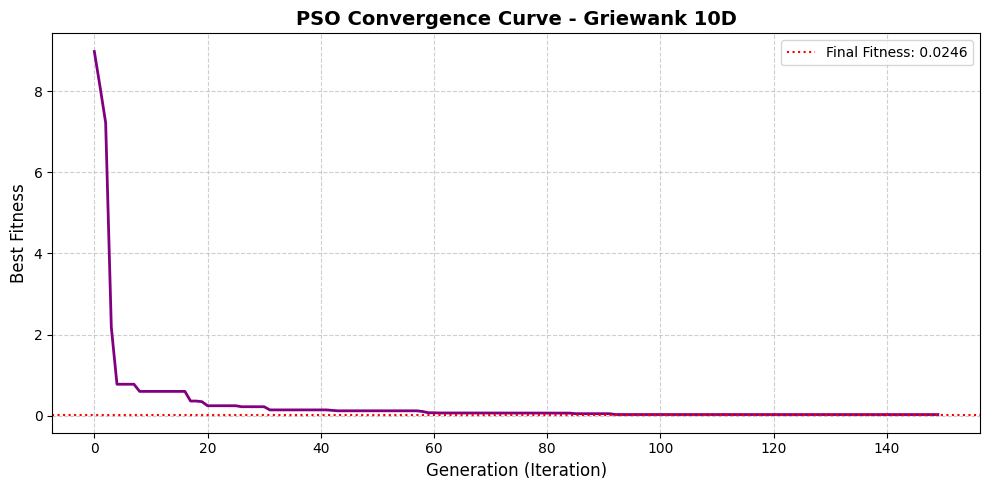

In [12]:
import matplotlib.pyplot as plt

# ==========================================
# PLOT DE CONVERGÈNCIA DEL PSO (GRIEWANK 10D)
# ==========================================

# 1. Posa aquí la configuració guanyadora del teu parameter sweep
best_w = 0.4
best_c1 = 2.0
best_c2 = 2.0

print(f"\nGenerant la corba de convergència per a w={best_w}, c1={best_c1}, c2={best_c2}...")

# 2. Executem el PSO una única vegada amb aquests paràmetres
pso_plot = PSO(func=griewank, n_dim=dimensions, pop=def_pop, max_iter=def_iter, 
               lb=lower_bound, ub=upper_bound, w=best_w, c1=best_c1, c2=best_c2)
pso_plot.run()

# L'historial del millor fitness a cada generació es guarda a gbest_y_hist
fitness_history = pso_plot.gbest_y_hist

# 3. Dibuixem la gràfica
plt.figure(figsize=(10, 5))
plt.plot(fitness_history, color='purple', linewidth=2)

plt.title(f'PSO Convergence Curve - Griewank 10D', fontsize=14, fontweight='bold')
plt.xlabel('Generation (Iteration)', fontsize=12)
plt.ylabel('Best Fitness', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Marquem el valor final obtingut
final_fitness = float(fitness_history[-1])
plt.axhline(y=final_fitness, color='red', linestyle=':', linewidth=1.5, 
            label=f'Final Fitness: {final_fitness:.4f}')
plt.legend()

plt.tight_layout()
plt.savefig('PSO_Griewank_Convergence.png', dpi=300)
plt.show()

🚀 Executant PSO amb record_mode=True per extreure les 3 mètriques...


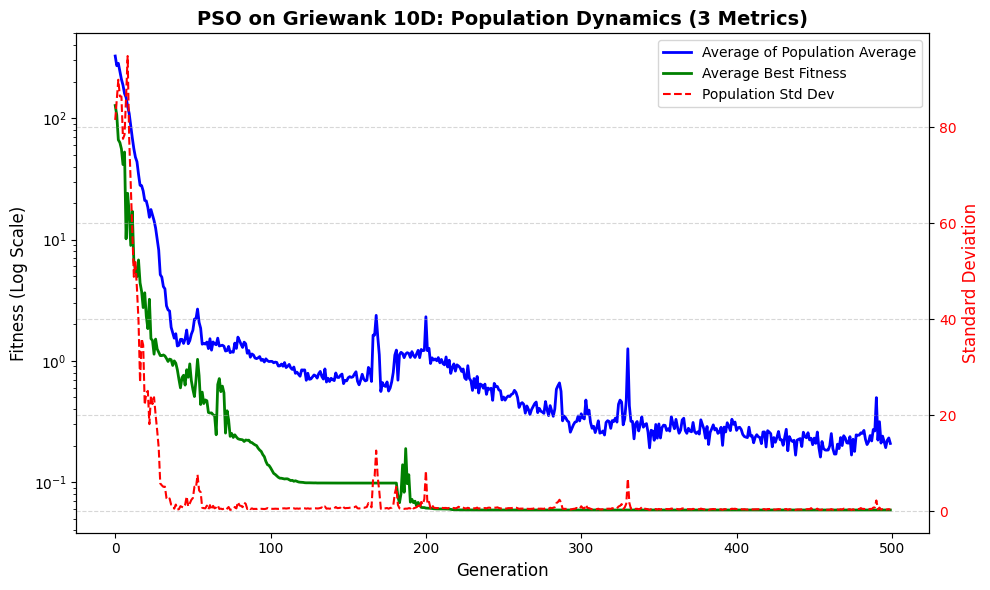

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sko.PSO import PSO

# 1. Definició de la funció Griewank i el calculador per poblacions
def griewank(x):
    part1 = sum(x**2) / 4000.0
    part2 = np.prod(np.cos(x / np.sqrt(np.arange(1, len(x) + 1))))
    return 1.0 + part1 - part2

def calc_fitness_pop(X):
    # Calcula el fitness per a cadascuna de les partícules (files de X)
    return np.array([griewank(ind) for ind in X])

dimensions = 10
lower_bound = [-600] * dimensions
upper_bound = [600] * dimensions
def_pop = 50
def_iter = 500

# Posa aquí la configuració guanyadora del teu escombrat
best_w = 0.4
best_c1 = 2.0
best_c2 = 2.0

print("🚀 Executant PSO amb record_mode=True per extreure les 3 mètriques...")

pso_metrics = PSO(func=griewank, n_dim=dimensions, pop=def_pop, max_iter=def_iter, 
                  lb=lower_bound, ub=upper_bound, w=best_w, c1=best_c1, c2=best_c2)

# ACTIVEM EL MODE RECORD PER GUARDAR L'HISTORIAL DE TOTES LES PARTÍCULES 
pso_metrics.record_mode = True
pso_metrics.run()

# Extraiem l'historial de posicions (X) per a cada generació 
X_history = pso_metrics.record_value['X']

# 2. Calculem les 3 mètriques per a cada generació
avg_fitness_hist = []
best_fitness_hist = []
std_fitness_hist = []

for pop_X in X_history:
    pop_fitness = calc_fitness_pop(pop_X)
    avg_fitness_hist.append(np.mean(pop_fitness))
    best_fitness_hist.append(np.min(pop_fitness))
    std_fitness_hist.append(np.std(pop_fitness))

# 3. CREACIÓ DEL PLOT AMB LES 3 MÈTRIQUES
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Generation', fontsize=12)
ax1.set_ylabel('Fitness (Log Scale)', fontsize=12)
# Usem escala logarítmica perquè l'error cau de milers a gairebé zero molt de pressa
ax1.set_yscale('log') 

# Línies de Mitjana i Millor Fitness
line1, = ax1.plot(avg_fitness_hist, label='Average of Population Average', color='blue', linewidth=2)
line2, = ax1.plot(best_fitness_hist, label='Average Best Fitness', color='green', linewidth=2)

# Segon eix Y (a la dreta) per a la Desviació Estàndard per evitar que quedi esclafada
ax2 = ax1.twinx()
ax2.set_ylabel('Standard Deviation', color='red', fontsize=12)
line3, = ax2.plot(std_fitness_hist, label='Population Std Dev', color='red', linestyle='--', linewidth=1.5)
ax2.tick_params(axis='y', labelcolor='red')

# Unifiquem les llegendes
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=10)

plt.title('PSO on Griewank 10D: Population Dynamics (3 Metrics)', fontweight='bold', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('PSO_Griewank_3Metrics.png', dpi=300)
plt.show()